In [5]:
# 0. MONTAR DRIVE
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Instalación de dependencias
!pip install -q transformers accelerate peft bitsandbytes datasets pandas faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 80.4 MB/s eta 0:00:00


In [ ]:
!pip list | grep -E "transformers|accelerate|peft|bitsandbytes|datasets|pandas|faiss"

accelerate                               1.11.0
bitsandbytes                             0.48.2
datasets                                 4.0.0
faiss-cpu                                1.12.0
geopandas                                1.1.1
pandas                                   2.2.2
pandas-datareader                        0.10.0
pandas-gbq                               0.30.0
pandas-stubs                             2.2.2.240909
peft                                     0.17.1
sentence-transformers                    5.1.2
sklearn-pandas                           2.2.0
tensorflow-datasets                      4.9.9
transformers                             4.57.1
vega-datasets                            0.9.0


In [ ]:
#@title 2. Autenticación en Hugging Face

from huggingface_hub import login

HF_TOKEN = ""
login(token=HF_TOKEN)

In [ ]:
# 3. Importamos las librerias

import pandas as pd #para manipular el archivo de los datos en excel
import numpy as np #para manejo de vectores y matrices
import torch #Pytorch, backend de los modelos
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from peft import PeftModel, PeftConfig, get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training
from datasets import load_dataset
import bitsandbytes as bnb #Módiulo de 8 bits para reducir memoria
import faiss #Para crear indices vectoriales

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

En esta etapa cargamos el archivo de Excel que contiene los pares de texto técnico y resumen en lenguaje sencillo. El archivo archivos_comparados.xlsx se encuentra en la ruta PROYECTO FINAL MAESTRIA V2/data/processed/archivos_comparados.xlsx

Después de cargar los datos en un DataFrame de pandas, realizaremos una exploración rápida:

Ver el tamaño del conjunto de datos

Inspeccionar las primeras filas para entender la estructura

Comprobar si hay valores nulos o faltantes.

Analizar la longitud de los textos técnicos vs. los resúmenes para entender la distribución de longitudes. Esto nos ayuda a determinar el tamaño máximo de secuencia (block size) para el modelo decoder y ver si necesitaremos truncar textos muy largos.

In [ ]:
# 4. Carga y exploración de datos

#Cargamos el archivo de datos que se seleccionaron por corresponder entre non_pls y pls
data_path = "/content/drive/MyDrive/Colab Notebooks/PROYECTO FINAL MAESTRIA V2/data/processed/archivos_comparados.xlsx"
df = pd.read_excel(data_path)

#verificamos número de filas y columnas
print("Número de filas y columnas", df.shape)

# Imprimimos las primeras 5 filas del dataset
print(df.head(5))

# Verificamos si hay valores nulos o faltantes en las columnas
print("\nValores nulos por columnas:\n", df.isnull().sum())

#Calculamos longitudes de los textos
df['len_non_pls_chars'] = df['non_pls'].astype(str).apply(len)
df['len_pls_chars'] = df['pls'].astype(str).apply(len)

print("\nLongitud media de texto técnico (caracteres): ", df['len_non_pls_chars'].mean())
print("\nLongitud media de resumen pls (carateres): ", df['len_pls_chars'].mean())
print("\nLongitud máxima de texto técnico (caracteres): ", df['len_non_pls_chars'].max())
print("\nLongitud máxima de resumen pls (carateres): ", df['len_pls_chars'].max())
print("\nLongitud mínima de texto técnico (caracteres): ", df['len_non_pls_chars'].min())
print("\nLongitud mínima de resumen pls (carateres): ", df['len_pls_chars'].min())

Número de filas y columnas (3563, 3)
  codigo_comun                                            non_pls  \
0     CD000006  Background\nApproximately 70% of women will ex...   
1     CD000009  Background \nAcupuncture and related technique...   
2     CD000012  Background\nAlternative institutional settings...   
3     CD000022  Background\nPatients treated with mechanical v...   
4     CD000024  Background\nStroke is the third leading cause ...   

                                                 pls  
0  Absorbable stitches for repair of episiotomy a...  
1  Do acupuncture and related therapies help smok...  
2  Alternative versus conventional institutional ...  
3  Topical antibiotics to help reduce death and r...  
4  Early treatment with blood‐thinning drugs for ...  

Valores nulos por columnas:
 codigo_comun    0
non_pls         0
pls             0
dtype: int64

Longitud media de texto técnico (caracteres):  4763.330620263822

Longitud media de resumen pls (carateres):  2972.40808

Configuración del Modelo Decoder (LLaMA) y LoRA

En esta sección cargaremos el modelo decoder (LLaMA) que usaremos para generar los resúmenes, y configuraremos la técnica LoRA para el fine-tuning.

Usaremos un modelo LLaMA pre-entrenado de tamaño manejable Llama 3.2 1B como base y sobre este realizaremos un fine tuning supervisado.

Información tomada del tutorial de la materia Modelos avanzados para el procesamiento de lenguaje natural: Tutorial semana 6:

Finetuning de LLMs:
Para la realización del Finetuning del modelo utilizaremos LoRA. El objetivo de LoRA es entrenar una matriz de pesos equivalente a $W$ entrenando menos pesos que $W$. Para lograr este objetivo, se entrenan dos matrices pequeñas que multiplicadas son equivilentes a $W$, de modo que $W = AB$. Si $W$ tiene dimensiones $q\times d$, entonces $A$ tendrá dimensiones $q\times r$ y $B$ dimensiones $r \times d$, de manera que entre $r$ sea menor, menos parámetros contienen las matrices $A$ y $B$.

Durante el entrenamiento, la técnica de LoRA consiste en congelar la matriz $W$ con los pesos originales del modelo, y entrenar únicamente las nuevas matrices de pesos $A$ y $B$, luego los resultados se suman para confirmar el resultado final.

En Transformers, las capas de Self-Attention usan matrices para proyectar las representaciones en Q, K y V (Query, Key y Value respectivamente). Para nuestro finetuning se realizara en las matrices Q y V de cada cabeza de atención por medio de las matrices de bajo rango que añade LoRA


In [ ]:
# 5. Carga del modelo Llama y aplicamos LoRA

from transformers import BitsAndBytesConfig

#Nombre del modelo
llama_model_name = "meta-llama/Llama-3.2-1B"

#Cargamos el tokenizador de Llama
llama_tokenizer = AutoTokenizer.from_pretrained(llama_model_name)

#Definimos la configuración de cuantización en 4 bits
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_enable_fp32_cpu_offload=True
)
#Cargamos el modelo de lenguaje causal LLama en 4 bits para ahorrar memoria lo que requiere la libreria bitsandbytes
llama_model = AutoModelForCausalLM.from_pretrained(llama_model_name, quantization_config=bnb_config, device_map='auto')

#Como Llama no trae el token de padding en el tokenizador por defecto se configura:
llama_tokenizer.pad_token = llama_tokenizer.eos_token

#se prepara el modelo para entrenamiento en 4 bits
llama_model = prepare_model_for_kbit_training(llama_model)
llama_model.config.use_cache = False
llama_model = prepare_model_for_kbit_training(llama_model)
llama_model.gradient_checkpointing_enable()

#Se define la configuración de LoRA
lora_config = LoraConfig(
    r = 8, #Rango de proyeccion de LoRA, mas pequeño significa menos parametros entrenables
    lora_alpha = 16, #escalar de LoRA, usualmente 2*r
    target_modules = ["q_proj", 'k_proj', 'v_proj', 'o_proj'], #Capas objetivo
    lora_dropout = 0.05, #dropout para ayudar a la generalización
    bias = "none", #no se va a ajustar los sesgos de las capas
    task_type = 'CAUSAL_LM' #definimos tipo de tarea como modelo causal
)

#Aplicamos LoRA al modelo base Llama
llama_model= get_peft_model(llama_model, lora_config)

#Se imprimen el número de parámetros entrenables vs el total de parametros para verificar que sean pocos
llama_model.print_trainable_parameters()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

trainable params: 1,703,936 || all params: 1,237,518,336 || trainable%: 0.1377


Para entrenar el modelo con nuestros pares de datos, necesitamos formatearlos de manera adecuada. Recordemos que vamos a hacer fine-tuning supervisado de un modelo de lenguaje causal (LLaMA) para que, dado un prompt que contiene el texto técnico, el modelo genere el texto en lenguaje sencillo.

Como LLaMA es un modelo decoder-only la forma de entrenarlo con pares entrada-salida es concatenar la entrada y la salida en una sola secuencia de tokens, separadas por un indicador, y luego aplicar una máscara de pérdida para que solo la parte de salida contribuya al cálculo de la pérdida. De esta forma, durante el entrenamiento el modelo leerá la entrada (sin ajustar sus pesos por ella) y solo será penalizado por sus tokens generados en la salida, aprendiendo a mapear de entrada a salida.

**Prompt a utilizar:**

El Prompt que utilizaremos sera del estilo de instrucciones y tendrá etiquetas para la instruccion, la entrada y la respuesta y de esta forma ayudar a delimitar donde termina la entrada y donde comienza la respuesta que el modelo debe generar


**Construcción del dataset:**

Crearemos una clase CustomDataset que extienda torch.utils.data.Dataset para preparar los ejemplos de entrenamiento. Esta clase realizará:


*   La creación del prompt concatenando Instrucción + Entrada + ### Respuesta con la respuesta correcta.
*   La tokenización de esta secuencia completa hasta un block_size máximo.
*   La creación de la máscara de labels donde los tokens del prompt + input se marcaran como -100 (esto indica a pytorch ignorar estos en la pérdida) y solo los tokens que corrsponden a la respuesta tendrán sus IDs como etiquetas para realizar el cálculo de la pérdida.
*   Devolvera un input_ids, attention_mask y labels que se usara en el entrenamiento

Se dividiran los datos en 90% para entrenamiento y 10% para validación de forma aleatoria para poder monitorear el rendimiento del modelo en datos no vistos durante el fine-tuning de tal forma que si se deben modificar hiperparámetros para evitar sobreajuste sea posible. También para poder tener reproducibilidad en los resultados se utiliza una semilla


In [ ]:
# DEFINIMOS EL PROMPT BASE

BASE_PROMPT = """Using the next instructions, write a plain-language summary for patients:
* Organize it using short, reader-friendly headings similar to those used in patient-oriented evidence summaries (e.g., Review question, Background, Study characteristics, Key results, Conclusions, Quality of evidence).
* Do not use the technical headings verbatim; instead, adapt them into simple, descriptive labels.
* Integrate all information into a clear, coherent, and easy-to-follow narrative.
* Keep the language at or below a 6th-grade reading level.
* Avoid jargon; if you must use a technical term, explain it in simple, familiar words.
* Use active voice, mostly short words (one or two syllables), and sentences of no more than 20 words.
* Organize the summary into short paragraphs of 3-5 sentences
* Use simple numbers or ratios (for example, 1 in 2) instead of percentages.
* Do not add, remove, or infer any information not present in the abstract.
* The summary should remain consistent regardless of the order of sentences in the original abstract.
* Provide only the summary as plain text. Do not use bold, italics, headings, asterisks, or any other formatting
* Do not provide comments or explanations.
* Target a total length of 300–500 words.
Here is the abstract of a biomedical study to summarize:"""

def format_sample(sample, base_prompt):
    '''
    Función para crear prompt a partir de un texto técnico
    '''
    non_pls = sample["non_pls"]

    prompt = (
        f"{base_prompt}\n\n"
        f"{non_pls}\n\n"
        "Plain-language summary:\n\n"
    )
    return prompt

In [ ]:
# 6. Configuración de los datasets y configuración del prompt
import random
from torch.utils.data import Dataset

#Acá definimos el tamaño máximo de secuencia que será entrada + salida
#La capacidad del modelo Llama es de 2048 y se va a manejar este BLOCK_SIZE intentando capturar la mayor parte de los textos.
BLOCK_SIZE = 2048

class CustomDataset(Dataset):
  def __init__(self, dataset, tokenizer, base_prompt):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.base_prompt = base_prompt

  def __len__(self):
      return len(self.dataset)

  def __getitem__(self, idx):
      sample = self.dataset[idx]
      non_pls = sample['non_pls']
      pls = sample['pls']
      self.tokenizer.pad_token = self.tokenizer.eos_token

      prompt = format_sample({'non_pls': non_pls}, self.base_prompt)

      prompt_enc = self.tokenizer(prompt, truncation=True, max_length=BLOCK_SIZE, add_special_tokens=False)
      prompt_len = len(prompt_enc['input_ids'])
      full_prompt = prompt + f"{pls}" + self.tokenizer.eos_token
      full_enc = self.tokenizer(full_prompt, truncation=True, max_length=BLOCK_SIZE, add_special_tokens=False)

      input_ids = full_enc['input_ids']
      attention_mask = full_enc['attention_mask']
      labels = [-100] * len(input_ids)
      labels[prompt_len:] = input_ids[prompt_len:]

      return {
          'input_ids': input_ids,
          'attention_mask': attention_mask,
          'labels': labels
      }

In [ ]:
# 6.b — Chunking de artículos y PLS por presupuesto de tokens
import re

#Calculamos el número  de tokens sin agregar especiales
def contar_tokens(texto: str) -> int:
    """
    Esta función uenta cuántos tokens ocupa un texto usando llama_tokenizer,
    sin agregar tokens especiales.
    """
    return len(llama_tokenizer(texto, add_special_tokens=False).input_ids)

#se hace segmentación en oraciones por regla simple
# Corta cuando encuentra ., ! o ? seguidos de espacios.
PATRON_CORTE_ORACION = re.compile(r'(?<=[\.!\?])\s+')


"""
Partir el TEXTO TÉCNICO en bloques por tokens respetando oraciones y con solapamiento opcional.
Idea:
- Vamos acumulando oraciones en un buffer hasta llegar al máximo de tokens permitido.
- Si una oración sola se pasa del límite, la partimos por palabras. Esto sería un caso extremo.
- Cuando cerramos un bloque y usamos solapamiento, tomamos las últimas oraciones del bloque anterior como “cola” para no perder contexto.
"""

def partir_texto_en_bloques(texto: str, max_tokens: int, solapamiento_tokens: int = 0):
    """
    Divide un texto largo en varios bloques, donde cada bloque tiene como máximo max_tokens tokens aproximadamete:

    - Primero se separa en oraciones.
    - Se arman bloques completos de oraciones.
    - Si una sola oración es demasiado grande, se parte por palabras.
    - Opcionalmente se agrega solapamiento para tener contexto compartido entre un bloque y el siguiente.
    """
    #Separamos texto en oraciones y limpiamos espacios
    oraciones = [s.strip() for s in re.split(PATRON_CORTE_ORACION, texto) if s.strip()]

    bloques = []         # lista final de bloques de texto
    buffer_oraciones = []  # oraciones que vamos juntando para el bloque actual
    buffer_tokens = 0      # cuántos tokens lleva el bloque actual

    for oracion in oraciones:
        tokens_oracion = contar_tokens(oracion)

        # Caso extremo: una sola oración ya supera max_tokens
        if tokens_oracion > max_tokens:
            # En este caso partimos por palabras
            palabras = oracion.split()
            bloque_palabras = []
            tokens_bloque_palabras = 0

            for palabra in palabras:
                tokens_palabra = contar_tokens(palabra + " ")
                # Si agregar esta palabra se pasa del máximo, cerramos ese mini-bloque
                if tokens_bloque_palabras + tokens_palabra > max_tokens and bloque_palabras:
                    bloques.append(" ".join(bloque_palabras).strip())
                    bloque_palabras = []
                    tokens_bloque_palabras = 0

                bloque_palabras.append(palabra)
                tokens_bloque_palabras += tokens_palabra

            # Lo que quede al final también es un bloque
            if bloque_palabras:
                bloques.append(" ".join(bloque_palabras).strip())
            continue  # seguimos con la siguiente oración

        # Caso normal: la oración cabe en el bloque actual
        if buffer_tokens + tokens_oracion <= max_tokens:
            buffer_oraciones.append(oracion)
            buffer_tokens += tokens_oracion
        else:
            # Cerramos el bloque actual porque ya se llenó
            if buffer_oraciones:
                bloques.append(" ".join(buffer_oraciones).strip())

            # Ahora armamos el nuevo bloque y, si hay solapamiento,
            # tomamos del bloque anterior las últimas oraciones
            if solapamiento_tokens > 0 and bloques:
                cola_oraciones = []
                tokens_cola = 0

                # Tomamos oraciones desde el final del último bloque
                for oracion_atras in reversed(re.split(PATRON_CORTE_ORACION, bloques[-1])):
                    o_limpia = oracion_atras.strip()
                    if not o_limpia:
                        continue
                    t_o = contar_tokens(o_limpia + " ")
                    if tokens_cola + t_o > solapamiento_tokens:
                        break
                    cola_oraciones.append(o_limpia)
                    tokens_cola += t_o

                # Armamos el nuevo buffer: cola + oración actual
                buffer_oraciones = list(reversed(cola_oraciones)) + [oracion]
                buffer_tokens = sum(contar_tokens(x + " ") for x in buffer_oraciones)
            else:
                # Sin solapamiento: el nuevo bloque empieza solo con esta oración
                buffer_oraciones = [oracion]
                buffer_tokens = tokens_oracion

    # Al final, si quedó algo en el buffer, lo agregamos
    if buffer_oraciones:
        bloques.append(" ".join(buffer_oraciones).strip())

    return bloques



"""
Partir el PLS en n partes para alinearlo con los bloques del texto técnico.

Idea:
- El input se dividió en N bloques (por tokens).
- Queremos dividir el PLS en N pedazos “parecidos” en tamaño,
proporcional a los tokens de cada bloque de entrada.
"""
def partir_pls_en_n_partes(pls_texto: str, n_partes: int, tokens_objetivo_por_parte):
    """
    Divide el texto PLS en n_partes, tratando de que cada parte
    tenga un tamaño de tokens proporcional al tamaño de su bloque
    de entrada.

    - Primero partimos el PLS por párrafos (saltos de línea).
    - Calculamos cuántos tokens tiene cada párrafo.
    - Asignamos “cuotas” de tokens por parte según tokens_objetivo_por_parte.
    - Vamos llenando cada parte con párrafos hasta llegar a la cuota.
    """
    # Separar PLS en párrafos (líneas no vacías)
    parrafos = [p.strip() for p in pls_texto.split('\n') if p.strip()]

    # Casos simples: sin párrafos o solo 1 parte
    if not parrafos or n_partes <= 1:
        return [pls_texto.strip()] * n_partes

    # Tokens por párrafo
    tokens_por_parrafo = [contar_tokens(p) for p in parrafos]
    total_tokens_parrafos = sum(tokens_por_parrafo)

    # Si por alguna razón total es 0, usamos número de palabras como fallback
    if total_tokens_parrafos <= 0:
        total_tokens_parrafos = len(" ".join(parrafos).split())

    # Aseguramos que cada parte tenga al menos peso 1
    pesos = [max(c, 1) for c in tokens_objetivo_por_parte]
    suma_pesos = sum(pesos)

    # Cuántos tokens “debería” tener cada parte de salida
    # se dividen los tokens del pls porcentualmente
    cuotas_tokens = [
        max(int(round(total_tokens_parrafos * (p / suma_pesos))), 1)
        for p in pesos
    ]

    partes_pls = []
    buffer_parrafos = []
    buffer_tokens = 0
    idx_parte = 0  # índice de la parte que estamos llenando

    for parrafo, tok_parrafo in zip(parrafos, tokens_por_parrafo):
        if idx_parte >= n_partes:
            break

        # Si todavía no llenamos la cuota de la parte actual, agregamos
        if buffer_tokens + tok_parrafo <= cuotas_tokens[idx_parte] or not buffer_parrafos:
            buffer_parrafos.append(parrafo)
            buffer_tokens += tok_parrafo
        else:
            # Cerramos la parte actual y pasamos a la siguiente
            partes_pls.append("\n".join(buffer_parrafos).strip())
            idx_parte += 1
            buffer_parrafos = [parrafo]
            buffer_tokens = tok_parrafo

    # Agregamos el último buffer
    if buffer_parrafos:
        partes_pls.append("\n".join(buffer_parrafos).strip())

    # Ajuste fino: que queden EXACTAMENTE n_partes
    if len(partes_pls) < n_partes:
        # Si faltan partes, repetimos la última
        partes_pls += [partes_pls[-1]] * (n_partes - len(partes_pls))
    elif len(partes_pls) > n_partes:
        # Si nos pasamos, las últimas se fusionan en la parte final
        partes_pls = partes_pls[:n_partes - 1] + ["\n".join(partes_pls[n_partes - 1:])]

    return partes_pls



#Construimos un prompt “de ejemplo” para medir cuántos tokens se come solamente el prompt sin texto técnico.

def construir_prompt_ejemplo(texto_entrada: str) -> str:
    """
    Prompt alineado con el entrenamiento:
    BASE_PROMPT + abstract + 'Plain-language summary:'

    """
    return (
        f"{BASE_PROMPT}\n\n"
        f"{texto_entrada}\n\n"
        "Plain-language summary:\n\n"
    )

# Tokens del prompt usando entrada vacía (sirve como aproximación)
tokens_prompt_solo = contar_tokens(construir_prompt_ejemplo(""))

# Reservamos presupuesto para la salida del modelo (PLS generado)
PRESUPUESTO_SALIDA_TOKENS = max(256, min(768, BLOCK_SIZE // 3))
MARGEN_SEGURIDAD_TOKENS   = 24

# Máximo de tokens que le podemos dar al TEXTO TÉCNICO
MAX_TOKENS_ENTRADA = max(
    64,
    BLOCK_SIZE - PRESUPUESTO_SALIDA_TOKENS - tokens_prompt_solo - MARGEN_SEGURIDAD_TOKENS
)

print(f"Tokens del prompt sin texto técnico: {tokens_prompt_solo}")
print(f"Máx tokens disponibles para TEXTO TÉCNICO: {MAX_TOKENS_ENTRADA}")


#Recorremos el DataFrame original y generamos nuevos registros con chunking alineado input ↔ PLS.

registros_expandidos = []

for fila in df.itertuples(index=False):
    texto_tecnico = str(getattr(fila, 'non_pls'))
    texto_pls     = str(getattr(fila, 'pls'))

    # 1) Partimos el texto técnico según el presupuesto de tokens
    bloques_tecnicos = partir_texto_en_bloques(
        texto_tecnico,
        max_tokens=MAX_TOKENS_ENTRADA,
        solapamiento_tokens=64
    )

    # Si no se obtuvo nada, saltamos
    if not bloques_tecnicos:
        continue

    #Calculamos cuántos tokens tiene cada bloque técnico
    tokens_por_bloque = [contar_tokens(x) for x in bloques_tecnicos]

    #Partimos el PLS en el mismo número de bloques que el input tratando de que cada parte tenga tamaño proporcional
    bloques_pls = partir_pls_en_n_partes(
        texto_pls,
        n_partes=len(bloques_tecnicos),
        tokens_objetivo_por_parte=tokens_por_bloque
    )

    # Emparejamos bloque técnico ↔ bloque PLS
    for bloque_tec, bloque_pls in zip(bloques_tecnicos, bloques_pls):
        registros_expandidos.append({
            'non_pls': bloque_tec,
            'pls': bloque_pls
        })

print(f"Registros originales: {len(df)} | Registros tras chunking: {len(registros_expandidos)}")

# Este será el origen para train/val
data_list = registros_expandidos

Tokens del prompt sin texto técnico: 207
Máx tokens disponibles para TEXTO TÉCNICO: 1135
Registros originales: 3563 | Registros tras chunking: 4968


In [ ]:
#Dividimos los datos en train y val
#data_list = df.to_dict('records')
random.shuffle(data_list)
split_idx = int(0.9*len(data_list))
train_data = data_list[:split_idx]
val_data = data_list[split_idx:]

#Ahora se instancian los datasets llamando la clase que creamos
train_dataset = CustomDataset(train_data, llama_tokenizer, BASE_PROMPT)
val_dataset = CustomDataset(val_data, llama_tokenizer, BASE_PROMPT)

#Verificams un ejemplo tokenizado para verificar la estructura
example = train_dataset[26]
print("Número de ejemplos de entrenamiento", len(train_dataset))
print("Número de ejempls del conjunto de validación", len(val_dataset))
print("Ejemplo tokens inputs", example['input_ids'][:30], "...")
print("Ejemplo tokens labels", example['labels'][:30], "...")
print("Ejemplo tokens attention_mask", example['attention_mask'][:30], "...")
#print("Tamaño de input_ids", example['input_ids'].shape)
print("Tamaño de input_ids", len(example['input_ids']))
#print("Tamaño de labels", example['labels'].shape)
print("Tamaño de labels", len(example['labels']))
#print("Tamaño de attention_mask", example['attention_mask'].shape)
print("Tamaño de attention_mask", len(example['attention_mask']))

Número de ejemplos de entrenamiento 4471
Número de ejempls del conjunto de validación 497
Ejemplo tokens inputs [16834, 279, 8278, 3770, 11, 3350, 264, 14733, 44658, 12399, 369, 6978, 627, 9, 1442, 279, 4113, 1495, 374, 2736, 264, 14733, 44658, 12399, 11, 2567, 433, 439, 374, 477] ...
Ejemplo tokens labels [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100] ...
Ejemplo tokens attention_mask [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...


Entrenamiento del Modelo con LoRA

Con el modelo LLaMA mas LoRA preparado y los datos formateados, podemos configurar el proceso define-tuning. Utilizaremos el Trainer de Hugging Face Transformers para que maneje internamente el bucle de entrenamiento, la optimización y también evaluar en el conjunto de validación.

Consideraciones para el entrenamiento:

*   Hiperparámetros: Los más importantes para el entrenamiento seraán el númerp de épocas "epochs", la tasa de aprendizaje "learning rate", el tamaño del lote y se utilizara una estrategia de acumulación de gradiente en caso de que el batch no pueda ser grande por limitaciones de memoria
*   Epezaremos la prueba con 3 epocas y dependiendo de los resultados se aumentará o disminuirá
*   El Learning rate que utilizaremos es 2e-5
*   Vamos a usar batch_size = 1 para asegurarnos por que los ejemplos son largos
*   Utilizamos Gradient Accumulation Steps para simular un batch de 8 antes de actualizar los gradientes
*   Evaluamos cada cantidad de pasos steps para monitorear la pérdida en validación

Se configura que le trainer la columna 'labels' para calcula la pérdida.



In [ ]:
example = val_dataset[0]
print("Input IDs:", example['input_ids'][:1048])
print("Labels:", example['labels'][:1048])
print("Attention Mask:", example['attention_mask'][:1048])

Input IDs: [16834, 279, 8278, 3770, 11, 3350, 264, 14733, 44658, 12399, 369, 6978, 627, 9, 1442, 279, 4113, 1495, 374, 2736, 264, 14733, 44658, 12399, 11, 2567, 433, 439, 374, 477, 1304, 1193, 17832, 51944, 311, 7417, 32373, 323, 92594, 627, 9, 13969, 279, 4221, 520, 477, 3770, 264, 220, 21, 339, 41327, 5403, 2237, 627, 9, 35106, 503, 71921, 26, 422, 499, 2011, 1005, 264, 11156, 4751, 11, 10552, 433, 304, 4382, 11, 11537, 4339, 627, 9, 5560, 4642, 7899, 11, 2875, 4339, 320, 606, 477, 1403, 48704, 4893, 705, 323, 23719, 315, 912, 810, 1109, 220, 868, 4339, 627, 9, 10995, 553, 279, 12399, 1139, 220, 18, 4235, 20, 2875, 43743, 627, 9, 5560, 4382, 5219, 477, 42338, 320, 2000, 3187, 11, 220, 16, 304, 220, 17, 8, 4619, 315, 54208, 627, 9, 3234, 539, 923, 11, 4148, 11, 477, 24499, 904, 2038, 539, 3118, 304, 279, 8278, 627, 9, 578, 12399, 1288, 7293, 13263, 15851, 315, 279, 2015, 315, 23719, 304, 279, 4113, 8278, 627, 9, 40665, 1193, 279, 12399, 2001, 912, 51594, 37666, 11, 6170, 11, 477, 4194

In [ ]:
def custom_collate_fn(batch):
    max_length = max([len(x["input_ids"]) for x in batch])

    input_ids = []
    attention_masks = []
    labels = []

    for item in batch:
      pad_id = llama_tokenizer.pad_token_id

      padded_input_ids = item["input_ids"] + [pad_id] * (max_length - len(item["input_ids"]))
      input_ids.append(padded_input_ids)

      padded_attention_mask = item["attention_mask"] + [0] * (max_length - len(item["attention_mask"]))
      attention_masks.append(padded_attention_mask)

      padded_labels = item["labels"] + [-100] * (max_length - len(item["labels"]))
      labels.append(padded_labels)

    return {
        "input_ids": torch.tensor(input_ids),
        "attention_mask": torch.tensor(attention_masks),
        "labels": torch.tensor(labels)
    }

In [ ]:
# 7. Entrenamiento del modelo Llama con LoRA
import os
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorForSeq2Seq

#Primero se crea la carpeta artifacts para guardar el modelo y salidas
artifacts_dir = "/content/drive/MyDrive/Colab Notebooks/PROYECTO FINAL MAESTRIA V2/artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

# Asegura flags recomendados con LoRA + 8bit
try: llama_model.gradient_checkpointing_enable()
except: pass
try: llama_model.enable_input_require_grads()
except: pass
llama_model.config.use_cache = False

#Definimos los Hiperparámetros para entrenamiento
epochs = 10
batch_size_per_device = 2 #número de ejemplos en cada paso
gradient_accumulation_steps = 4 #para simular un batch de 8 en total
eval_steps = 200 #frecuencia de evaluación
learning_rate = 5e-4 #tasa de aprendizaje inicial
warmup_ratio = 0.1 #
max_grad_norm = 1.0  #para evitar explosion de gradientes
SEED = seed


#Calculamos el número total de pasos de entrenamiento
train_steps_per_epoch = len(train_dataset) // (batch_size_per_device * gradient_accumulation_steps)
total_training_steps = train_steps_per_epoch * epochs

training_args = TrainingArguments(
    output_dir = os.path.join(artifacts_dir, "trainer_output"),
    num_train_epochs = epochs,
    per_device_train_batch_size = batch_size_per_device,
    per_device_eval_batch_size = 1,
    gradient_accumulation_steps = gradient_accumulation_steps,
    eval_strategy = "steps",
    eval_steps = eval_steps,
    logging_steps = eval_steps,
    save_steps = eval_steps,
    save_total_limit = 2,
    learning_rate = learning_rate,
    warmup_ratio = warmup_ratio,
    bf16 = True, #entrenaiento mas estable
    fp16 = False, #punto flotante de 16 bits para entrenamiento
    optim = "adamw_torch",
    #optim = "paged_adamw_8bit",
    report_to = "tensorboard",
    remove_unused_columns = False,
    load_best_model_at_end = True,
    metric_for_best_model = "loss",
    greater_is_better = False,
    run_name = "LoRA_finetuning_PLS"
)

#Definimos que el modelo espera "labels" en el forward para el calculo de loss
llama_model.config.label_names = ["labels"]

# Definimos el callback para early stopping
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=3,  # Detiene si no mejora en 5 evaluaciones
    early_stopping_threshold=0.001  # Mejora mínima requerida (0.01%)
)

# Definimos el data collator para Seq2Seq
"""data_collator = DataCollatorForSeq2Seq(
    tokenizer=llama_tokenizer,
    model=llama_model,
    padding='longest',
    label_pad_token_id=-100,
    max_length=BLOCK_SIZE
)"""

#Definimos el trainer
trainer = Trainer(
    model = llama_model,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    args = training_args,
    data_collator=custom_collate_fn,
    callbacks=[early_stopping_callback]

)

#Iniciamos el entrenamiento
trainer.train()



Step,Training Loss,Validation Loss
200,1.750700,1.798679
400,1.675900,1.683774
600,1.595300,1.635675
800,1.563700,1.614381
1000,1.562800,1.603287
1200,1.558500,1.595591
1400,1.547200,1.590487
1600,1.539800,1.585858
1800,1.527700,1.582639
2000,1.529500,1.578950


TrainOutput(global_step=3600, training_loss=1.5546520063612197, metrics={'train_runtime': 6651.0583, 'train_samples_per_second': 6.722, 'train_steps_per_second': 0.84, 'total_flos': 2.8052457529706496e+17, 'train_loss': 1.5546520063612197, 'epoch': 6.440071556350626})

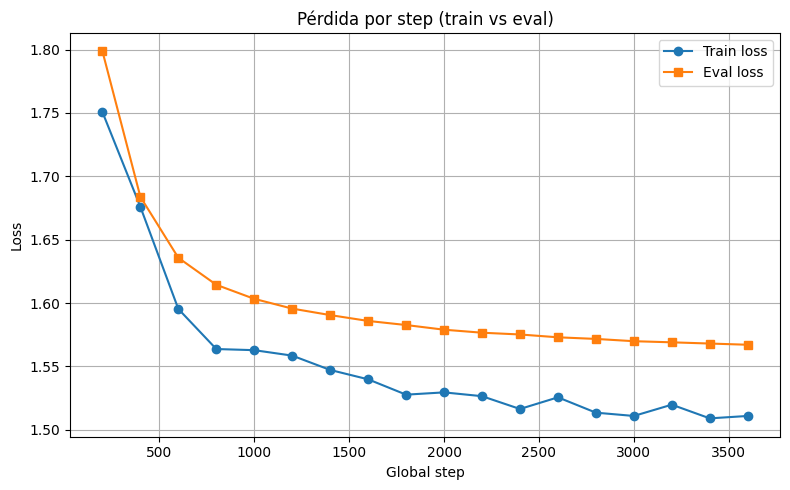

In [ ]:
# Gráfica sencilla de pérdida por step (train vs eval)

import pandas as pd
import matplotlib.pyplot as plt

#Logs a DataFrame
hist = pd.DataFrame(trainer.state.log_history)

#Separar train y eval por step
train_df = hist[hist.get("loss").notna()][["step", "loss"]].copy()
eval_df  = hist[hist.get("eval_loss").notna()][["step", "eval_loss"]].copy()

#Gráfica
plt.figure(figsize=(8, 5))

if len(train_df):
    plt.plot(train_df["step"], train_df["loss"],
             marker='o', linestyle='-', label="Train loss")

if len(eval_df):
    plt.plot(eval_df["step"], eval_df["eval_loss"],
             marker='s', linestyle='-', label="Eval loss")

plt.title("Pérdida por step (train vs eval)")
plt.xlabel("Global step")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




Guardado del Modelo Fine-Tuned (LoRA) y Artefactos Finales

Se guardan los resultados para poder utilizarlos en el despliegue o inferencia:

*   Guardado de los adaptadores LoRA: Solo contienen los pesos de las matrices A y B.
*   Guardado del modleo completo fusionado con LoRA.



In [ ]:
# 8. Guardado del modelo Fine-Tuned (LoRA) y Artefactos Finales

from peft import PeftModel, PeftConfig

# Guardamos los pesos de LoRA entrenados
model_save_dir = os.path.join(artifacts_dir, "llama_pls_lora_v6")
os.makedirs(model_save_dir, exist_ok=True)

# Guardamos solo los pesos de LoRA
llama_model.save_pretrained(model_save_dir)
print(f"Adaptadores de LoRA guardados en {model_save_dir}")

# Guardamos el modelo completo fusionado con LoRA
full_model_dir = os.path.join(artifacts_dir, "llama_pls_full_v6")
os.makedirs(full_model_dir, exist_ok=True)

# Instanciamos un PeftModel para fusionar
peft_model = PeftModel.from_pretrained(llama_model, model_save_dir)
merged_model = peft_model.merge_and_unload()  # Fusiona LoRA con el modelo base
merged_model.save_pretrained(full_model_dir)
print(f"Modelo completo fusionado con LoRA guardado en {full_model_dir}")



Adaptadores de LoRA guardados en /content/drive/MyDrive/Colab Notebooks/PROYECTO FINAL MAESTRIA V2/artifacts/llama_pls_lora_v6


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:585: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.o_proj.

Modelo completo fusionado con LoRA guardado en /content/drive/MyDrive/Colab Notebooks/PROYECTO FINAL MAESTRIA V2/artifacts/llama_pls_full_v6


Prueba de inferencia:
Cargamos el modelo base LLaMA y aplicamos el adaptador LoRA guardado simulando un escenario de despliegue. Luego tomamos un texto técnico de prueba y construimos el prompt de la misma manera que en entrenamiento.

Usamos model.generate para que produzca una continuación de texto, que debería ser el resumen en lenguaje sencillo y decodificamos los tokens generados para poder leer el resultado.



In [ ]:

# 9. Prueba de Inferencia

from peft import PeftModel

#Cargamos el modelo base y le pegamos el adaptador LoRA entrenado
base_model = AutoModelForCausalLM.from_pretrained(
    llama_model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

#Tokenizer para inferencia
inference_tokenizer = AutoTokenizer.from_pretrained(llama_model_name)
if inference_tokenizer.pad_token is None:
    inference_tokenizer.pad_token = inference_tokenizer.eos_token  # aseguramos pad_token

# argamos los pesos LoRA que entrenamos y se los montamos al modelo base
model_with_lora = PeftModel.from_pretrained(base_model, model_save_dir)
model_with_lora.eval()  # ponemos el modleo en modo evaluación
model_with_lora.config.use_cache = True  # en inferencia sí ayuda el cache

#Función para armar el prompt EXACTAMENTE igual al entrenamiento
def build_inference_prompt(texto_tecnico: str) -> str:
    """
    Construye el prompt de inferencia igual al usado en el fine-tuning:

    BASE_PROMPT
    <texto técnico>
    Plain-language summary:
    """
    return (
        f"{BASE_PROMPT}\n\n"
        f"{texto_tecnico}\n\n"
        "Plain-language summary:\n\n"
    )

#Tomamos un ejemplo de prueba del conjunto de validación (ya chunqueado)
test_example = val_data[0]
text_tech = test_example["non_pls"]
true_summary = test_example["pls"]

print("=== EJEMPLO DE PRUEBA ===")
print("Texto técnico de prueba (recortado):\n", text_tech[:800], "...\n")
print("Resumen verdadero (esperado, recortado):\n", true_summary[:800], "...\n")

#Construimos el prompt de inferencia
prompt = build_inference_prompt(text_tech)

#Lo tokenizamos. Aquí usamos BLOCK_SIZE para no pasarnos de la ventana total.
encoded = inference_tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=BLOCK_SIZE
)

input_ids = encoded["input_ids"].to(model_with_lora.device)
attention_mask = encoded["attention_mask"].to(model_with_lora.device)

#Generamos la respuesta con el modelo fine-tuned
#Usamos max_new_tokens ligado al PRESUPUESTO_SALIDA_TOKENS que definimos arriba
with torch.no_grad():
    generated_ids = model_with_lora.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=PRESUPUESTO_SALIDA_TOKENS,
        num_beams=2,                      # beam  para más coherencia
        early_stopping=True,
        pad_token_id=inference_tokenizer.eos_token_id,
        eos_token_id=inference_tokenizer.eos_token_id,
    )

decoded_text = inference_tokenizer.decode(generated_ids[0], skip_special_tokens=True)

#Nos quedamos solo con lo que viene después de "Plain-language summary:"
if "Plain-language summary:" in decoded_text:
    generated_summary = decoded_text.split("Plain-language summary:")[-1].strip()
else:
    #Por si acaso el modelo no repite el ancla tal cual
    generated_summary = decoded_text.strip()

print("\n=== RESUMEN GENERADO POR EL MODELO ===\n")
print(generated_summary)

`torch_dtype` is deprecated! Use `dtype` instead!


=== EJEMPLO DE PRUEBA ===
Texto técnico de prueba (recortado):
 Background
Schizophrenia is a chronic, disabling and severe mental disorder, characterised by disturbance in perception, thought, language, affect and motor behaviour. Chlorpromazine and clotiapine are among antipsychotic drugs used for the treatment of people with schizophrenia. Objectives
To determine the clinical effects, safety and cost‐effectiveness of chlorpromazine compared with clotiapine for adults with schizophrenia. Search methods
We searched Cochrane Schizophrenia's Trials Register (last update search 16/01/2016), which is based on regular searches of CINAHL, BIOSIS, AMED, Embase, PubMed, MEDLINE, PsycINFO and clinical trials registries. There are no language, date, document type, or publication status limitations for inclusion of records in the Register. Selection criteria
All ...

Resumen verdadero (esperado, recortado):
 Direct comparison of two antipsychotics (chlorpromazine versus clotiapine) for treating 

In [ ]:
# 10. Inferencia con beam, top-p y top-k con el mismo prompt del entrenamiento
from transformers import GenerationConfig

# Aquí reutilizamos:
# - model_with_lora definido en la celda 9
# - inference_tokenizer
# - BASE_PROMPT, PRESUPUESTO_SALIDA_TOKENS

def build_inference_prompt_para_modos(texto_tecnico: str) -> str:
    """
    Mismo estilo de prompt que en el fine-tuning:

    BASE_PROMPT
    <texto técnico>
    Plain-language summary:
    """
    return (
        f"{BASE_PROMPT}\n\n"
        f"{texto_tecnico}\n\n"
        "Plain-language summary:\n\n"
    )

def limpiar_salida(decoded: str) -> str:
    """
    Toma el texto completo generado, se queda con lo que viene después
    de 'Plain-language summary:' y hace un recorte suave en longitud.
    """
    #Nos quedamos con la parte posterior al ancla del prompt
    if "Plain-language summary:" in decoded:
        salida = decoded.split("Plain-language summary:")[-1].strip()
    else:
        salida = decoded.strip()

    #Recorte suave por número de oraciones / palabras
    import re
    oraciones = re.split(r'(?<=[.!?])\s+', salida)
    oraciones = [s.strip() for s in oraciones if s.strip()]
    #Por ahora dejamos, por ejemplo, máximo 6 oraciones
    oraciones = oraciones[:6]
    texto = " ".join(oraciones)

    palabras = texto.split()
    if len(palabras) > 900:
        texto = " ".join(palabras[:900])

    return texto

def generar_resumen_modo(
    modelo,
    tokenizer,
    texto_tecnico: str,
    modo: str = "top_p",         # "beam", "top_p", "top_k"
    max_new_tokens: int = PRESUPUESTO_SALIDA_TOKENS,
    temperature: float = 0.7,
    top_p: float = 0.9,
    top_k: int = 50,
    num_beams: int = 4,
    repetition_penalty: float = 1.08,
    no_repeat_ngram_size: int = 4,
) -> str:
    """
    Genera un resumen para un texto técnico usando diferentes modos de decodificación:

    - modo = "beam"  -> beam search determinista
    - modo = "top_p" -> nucleus sampling
    - modo = "top_k" -> k-sampling
    """

    prompt = build_inference_prompt_para_modos(texto_tecnico)

    codificado = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=BLOCK_SIZE
    )
    input_ids = codificado["input_ids"].to(modelo.device)
    attention_mask = codificado["attention_mask"].to(modelo.device)

    #configuración de generación según el modo
    if modo == "beam":
        gen_cfg = GenerationConfig(
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=num_beams,
            early_stopping=True,
            length_penalty=1.0,
            repetition_penalty=repetition_penalty,
            no_repeat_ngram_size=no_repeat_ngram_size,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    else:
        #Samplin, ojo no podemos mezclar beams con do_sample
        gen_cfg = GenerationConfig(
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            repetition_penalty=repetition_penalty,
            no_repeat_ngram_size=no_repeat_ngram_size,
            num_beams=1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    with torch.no_grad():
        salida_ids = modelo.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            generation_config=gen_cfg
        )

    texto_decodificado = tokenizer.decode(salida_ids[0], skip_special_tokens=True)
    return limpiar_salida(texto_decodificado)


#PRUEBA CON UN MISMO EJEMPLO PARA LAS DOS FORMAS DE GENERACIÓN

ejemplo_val = val_data[0]
texto_tecnico_ej = ejemplo_val["non_pls"]
pls_referencia = ejemplo_val["pls"]

print("Texto técnico (preview):\n", texto_tecnico_ej[:800], "...\n")
print("Resumen de referencia (preview):\n", pls_referencia[:500], "...\n")

print("=== Beam search ===")
print(generar_resumen_modo(
    model_with_lora,
    inference_tokenizer,
    texto_tecnico_ej,
    modo="beam",
    num_beams=4
))

print("\n=== Sampling (top-p + top-k")
print(generar_resumen_modo(
    model_with_lora,
    inference_tokenizer,
    texto_tecnico_ej,
    modo="top_p",
    temperature=0.7,
    top_p=0.9,
    top_k=50
))



Texto técnico (preview):
 Background
Schizophrenia is a chronic, disabling and severe mental disorder, characterised by disturbance in perception, thought, language, affect and motor behaviour. Chlorpromazine and clotiapine are among antipsychotic drugs used for the treatment of people with schizophrenia. Objectives
To determine the clinical effects, safety and cost‐effectiveness of chlorpromazine compared with clotiapine for adults with schizophrenia. Search methods
We searched Cochrane Schizophrenia's Trials Register (last update search 16/01/2016), which is based on regular searches of CINAHL, BIOSIS, AMED, Embase, PubMed, MEDLINE, PsycINFO and clinical trials registries. There are no language, date, document type, or publication status limitations for inclusion of records in the Register. Selection criteria
All ...

Resumen de referencia (preview):
 Direct comparison of two antipsychotics (chlorpromazine versus clotiapine) for treating schizophrenia 
Review question 
The aim of thi

In [ ]:
#FUSIÓN de modelo base con LoRS para la v6 pad=eos, sin resize + verificación de que no queden claves LoRA
import os, shutil, json, torch, glob
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

#Rutas que necesito
artifacts_dir  = "/content/drive/MyDrive/Colab Notebooks/PROYECTO FINAL MAESTRIA V2/artifacts"
lora_dir       = os.path.join(artifacts_dir, "llama_pls_lora_v6")   # adapters entrenados
full_model_dir = os.path.join(artifacts_dir, "llama_pls_full_v6")   # carpeta final


#Limpiamos la carpeta FULL
if os.path.isdir(full_model_dir):
    shutil.rmtree(full_model_dir)
os.makedirs(full_model_dir, exist_ok=True)

#utilizamos el modelo base limpio enFP16, no el cuantizado

base_model_name_or_path = None
try:
    base_model_name_or_path = llama_model.config._name_or_path
except NameError:
    pass
#si no, se lee del adapter_config.json
if base_model_name_or_path is None:
    with open(os.path.join(lora_dir, "adapter_config.json"), "r", encoding="utf-8") as f:
        base_model_name_or_path = json.load(f).get("base_model_name_or_path", "meta-llama/Llama-3.2-1B")

print("Base model:", base_model_name_or_path)

#Cargamos base limpio en CPU FP16 (sin cuantización)
try:
    base_model_clean = AutoModelForCausalLM.from_pretrained(
        base_model_name_or_path,
        device_map="cpu",
        torch_dtype=torch.float16,
        use_safetensors=True,
        token=HF_TOKEN
    )
except TypeError:
    base_model_clean = AutoModelForCausalLM.from_pretrained(
        base_model_name_or_path,
        device_map="cpu",
        torch_dtype=torch.float16,
        use_safetensors=True
    )

#Tokenizer del base. En v6: pad = eos.
try:
    tokenizer = llama_tokenizer
except NameError:
    tokenizer = AutoTokenizer.from_pretrained(base_model_name_or_path, use_fast=True, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # v3

#Cargar LoRA y fusionar
print("Cargando adapters LoRA de:", lora_dir)
peft_model = PeftModel.from_pretrained(base_model_clean, lora_dir)

print("Fusionando LoRA  FULL…")
merged_model = peft_model.merge_and_unload()

#Se Guarda FULL en formato HF (safetensors + config + tokenizer)
merged_model.save_pretrained(full_model_dir, safe_serialization=True)
tokenizer.save_pretrained(full_model_dir)

#Nos aseguramos que no queden archivos del adapter dentro del FULL
for fn in ("adapter_config.json", "adapter_model.safetensors"):
    p = os.path.join(full_model_dir, fn)
    if os.path.exists(p):
        os.remove(p)

#Verificación: el FULL no debe tener claves 'lora'
m_check = AutoModelForCausalLM.from_pretrained(
    full_model_dir, device_map="cpu", torch_dtype=torch.float16, use_safetensors=True
)
num_lora = sum("lora" in k.lower() for k in m_check.state_dict().keys())
print("N° de claves con 'lora' en FULL:", num_lora)
print("FULL limpio guardado en:", full_model_dir)

Base model: meta-llama/Llama-3.2-1B
Cargando adapters LoRA de: /content/drive/MyDrive/Colab Notebooks/PROYECTO FINAL MAESTRIA V2/artifacts/llama_pls_lora_v6
Fusionando LoRA  FULL…
N° de claves con 'lora' en FULL: 0
FULL limpio guardado en: /content/drive/MyDrive/Colab Notebooks/PROYECTO FINAL MAESTRIA V2/artifacts/llama_pls_full_v6
